In [2]:
import cv2
import numpy as np
import os
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

# 💡 No MediaPipe needed at all!
# cv2 handles everything — reading videos and resizing frames
# numpy stores our frame arrays
# tqdm gives us the progress bar
# matplotlib lets us visualize sample frames

print("✅ All imports successful!")

✅ All imports successful!


In [3]:
DATASET_PATH    = "SL"        # Your gesture videos folder
SAVE_PATH       = "MP_Data"   # Where processed data will be saved
SEQUENCE_LENGTH = 30          # Frames to extract per video
IMG_SIZE        = 64          # Resize each frame to 64×64 pixels

# 💡 IMG_SIZE = 64 means each frame becomes a 64×64 pixel image
#    Small enough to train fast, big enough to capture hand shape

os.makedirs(SAVE_PATH, exist_ok=True)

# Get all gesture class names (folder names inside SL/)
gestures = sorted([
    g for g in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, g))
])

print(f"✅ Dataset path: {DATASET_PATH}")
print(f"📂 Total gestures found: {len(gestures)}")
print(f"🗂️  Gestures: {gestures}")

✅ Dataset path: SL
📂 Total gestures found: 2000
🗂️  Gestures: ['a', 'a lot', 'abdomen', 'able', 'about', 'above', 'accent', 'accept', 'accident', 'accomplish', 'accountant', 'across', 'act', 'action', 'active', 'activity', 'actor', 'adapt', 'add', 'address', 'adjective', 'adjust', 'admire', 'admit', 'adopt', 'adult', 'advanced', 'advantage', 'adverb', 'affect', 'afraid', 'africa', 'after', 'afternoon', 'again', 'against', 'age', 'agenda', 'ago', 'agree', 'agreement', 'ahead', 'aid', 'aim', 'airplane', 'alarm', 'alcohol', 'algebra', 'all', 'all day', 'allergy', 'alligator', 'allow', 'almost', 'alone', 'alphabet', 'already', 'also', 'always', 'amazing', 'america', 'amputate', 'analyze', 'anatomy', 'and', 'angel', 'angle', 'angry', 'animal', 'anniversary', 'announce', 'annoy', 'another', 'answer', 'any', 'anyway', 'apart', 'apartment', 'apostrophe', 'appear', 'appetite', 'apple', 'appointment', 'appreciate', 'approach', 'appropriate', 'approve', 'april', 'archery', 'area', 'argue', 'arizo

In [4]:
def process_video(video_path):
    """
    Opens a video file → extracts SEQUENCE_LENGTH evenly spaced frames
    → resizes each to IMG_SIZE × IMG_SIZE → returns shape (30, 64, 64, 1)
    """
    cap = cv2.VideoCapture(video_path)
    # 💡 Opens the video file for reading

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    # 💡 How many frames does this video have in total?

    if total_frames == 0:
        cap.release()
        return np.zeros((SEQUENCE_LENGTH, IMG_SIZE, IMG_SIZE, 1))
        # 💡 Safety: if video is empty/corrupt, return blank array
        #    Shape: (30 frames, 64 pixels, 64 pixels, 1 channel)

    # Pick 30 evenly spaced frame positions
    frame_indices = np.linspace(0, total_frames - 1, SEQUENCE_LENGTH, dtype=int)
    # 💡 Example: 90-frame video → picks frames at positions [0, 3, 6, ..., 89]
    #    This works for any video length — short or long

    sequence = []

    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        # 💡 Jump to frame number idx in the video

        ret, frame = cap.read()
        # 💡 Read that frame — ret=True means success, frame=the image

        if ret:
            # Convert to grayscale — sign language shape matters, not color
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            # 💡 Grayscale reduces data from 3 color channels to 1
            #    This makes training 3× faster with minimal accuracy loss

            resized = cv2.resize(gray, (IMG_SIZE, IMG_SIZE))
            # 💡 Resize to 64×64 — standardizes all frames to same size
            #    The model needs all inputs to be identical dimensions

            normalized = resized / 255.0
            # 💡 Divide by 255 to get values between 0 and 1
            #    Neural networks train much better with small numbers (0-1)
            #    rather than large ones (0-255)

            sequence.append(normalized.reshape(IMG_SIZE, IMG_SIZE, 1))
            # 💡 reshape adds the channel dimension: (64,64) → (64,64,1)
            #    The "1" means 1 color channel (grayscale)
        else:
            sequence.append(np.zeros((IMG_SIZE, IMG_SIZE, 1)))
            # 💡 Failed frame? Add blank frame as placeholder

    cap.release()
    return np.array(sequence)
    # 💡 Final shape: (30, 64, 64, 1)
    #    30 frames, each 64×64 pixels, 1 color channel


print("✅ Helper function ready!")

✅ Helper function ready!


Testing on: SL\a\01610.mp4
✅ Output shape: (30, 64, 64, 1)
   Expected:     (30, 64, 64, 1)
   Min value: 0.00  Max value: 0.99


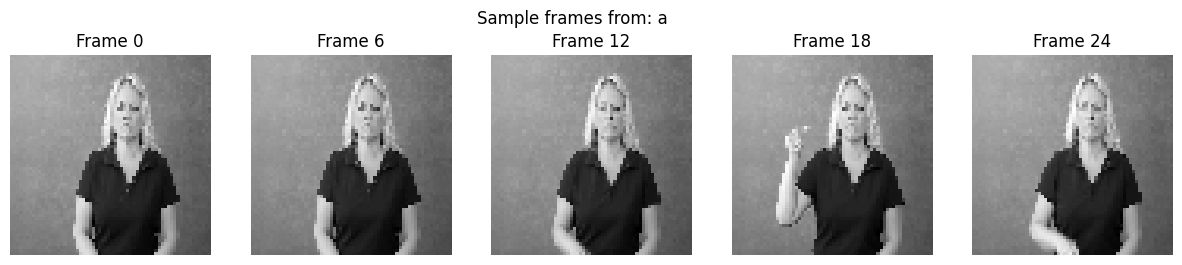

In [5]:
#  testing on ONE video first before processing 5GB!
test_gesture = gestures[0]
test_folder  = os.path.join(DATASET_PATH, test_gesture)
test_video   = os.listdir(test_folder)[0]
test_path    = os.path.join(test_folder, test_video)

print(f"Testing on: {test_path}")
sample_sequence = process_video(test_path)

print(f"✅ Output shape: {sample_sequence.shape}")
print(f"   Expected:     (30, 64, 64, 1)")
print(f"   Min value: {sample_sequence.min():.2f}  Max value: {sample_sequence.max():.2f}")
# 💡 Min should be 0.0 and Max should be ≤ 1.0 (normalized correctly)

# Show 5 sample frames from the video
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    frame_idx = i * 6  # Show frames 0, 6, 12, 18, 24
    ax.imshow(sample_sequence[frame_idx].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    ax.set_title(f"Frame {frame_idx}")
    ax.axis('off')
plt.suptitle(f"Sample frames from: {test_gesture}")
plt.show()
# 💡 This visually confirms our frames look correct
#    You should see 5 snapshots of the sign being performed

In [6]:
print(f"🚀 Processing {len(gestures)} gesture classes...\n")

for gesture in tqdm(gestures, desc="Overall Progress"):
    gesture_folder     = os.path.join(DATASET_PATH, gesture)
    save_gesture_path  = os.path.join(SAVE_PATH, gesture)
    os.makedirs(save_gesture_path, exist_ok=True)

    video_files = [
        f for f in os.listdir(gesture_folder)
        if f.lower().endswith(('.mp4', '.avi'))
    ]

    if len(video_files) == 0:
        print(f"⚠️  No videos in: {gesture}")
        continue

    for i, video_file in enumerate(video_files):
        video_path = os.path.join(gesture_folder, video_file)
        sequence   = process_video(video_path)
        np.save(os.path.join(save_gesture_path, f"{i}.npy"), sequence)
        # 💡 Saves each processed video as gesture/0.npy, gesture/1.npy etc.

print("\n✅ Preprocessing complete! Data saved to:", SAVE_PATH)

🚀 Processing 2000 gesture classes...



Overall Progress:   0%|          | 0/2000 [00:00<?, ?it/s]


✅ Preprocessing complete! Data saved to: MP_Data


In [7]:
print("📊 Verification Report:")
print("-" * 45)

total = 0
for gesture in gestures:
    path  = os.path.join(SAVE_PATH, gesture)
    count = len(os.listdir(path)) if os.path.exists(path) else 0
    total += count
    print(f"  {gesture:25s} → {count:4d} sequences")

print("-" * 45)
print(f"  Total sequences: {total}")

# Check one file shape
sample = np.load(os.path.join(SAVE_PATH, gestures[0], "0.npy"))
print(f"\n📐 Shape of one sequence: {sample.shape}")
print(f"   Expected: (30, 64, 64, 1)")

📊 Verification Report:
---------------------------------------------
  a                         →    5 sequences
  a lot                     →    7 sequences
  abdomen                   →    5 sequences
  able                      →    6 sequences
  about                     →    7 sequences
  above                     →    5 sequences
  accent                    →    5 sequences
  accept                    →    8 sequences
  accident                  →   13 sequences
  accomplish                →    5 sequences
  accountant                →    5 sequences
  across                    →    7 sequences
  act                       →    5 sequences
  action                    →    6 sequences
  active                    →    5 sequences
  activity                  →    5 sequences
  actor                     →    6 sequences
  adapt                     →    6 sequences
  add                       →   10 sequences
  address                   →    5 sequences
  adjective                 →  

In [8]:
# The 20 gestures we'll train on first
SELECTED_GESTURES = [
    'hello', 'yes', 'no', 'please', 'thank you',
    'sorry', 'help', 'good', 'bad', 'eat',
    'drink', 'water', 'home', 'school', 'love',
    'friend', 'go', 'stop', 'what', 'where'
]

# Verify all selected gestures exist in our processed data
print("Checking selected gestures in MP_Data...\n")
confirmed = []

for gesture in SELECTED_GESTURES:
    path  = os.path.join(SAVE_PATH, gesture)
    if os.path.exists(path):
        count = len(os.listdir(path))
        confirmed.append(gesture)
        print(f"  ✅ {gesture:15s} → {count} sequences")
    else:
        print(f"  ❌ {gesture:15s} → NOT FOUND")

print(f"\n✅ {len(confirmed)} out of {len(SELECTED_GESTURES)} gestures confirmed!")

Checking selected gestures in MP_Data...

  ✅ hello           → 4 sequences
  ✅ yes             → 12 sequences
  ✅ no              → 11 sequences
  ✅ please          → 7 sequences
  ✅ thank you       → 7 sequences
  ✅ sorry           → 7 sequences
  ✅ help            → 14 sequences
  ✅ good            → 10 sequences
  ✅ bad             → 10 sequences
  ✅ eat             → 7 sequences
  ✅ drink           → 15 sequences
  ✅ water           → 9 sequences
  ✅ home            → 7 sequences
  ✅ school          → 9 sequences
  ✅ love            → 7 sequences
  ✅ friend          → 7 sequences
  ✅ go              → 15 sequences
  ✅ stop            → 5 sequences
  ✅ what            → 12 sequences
  ✅ where           → 7 sequences

✅ 20 out of 20 gestures confirmed!


In [1]:
import cv2
import numpy as np
import os

GESTURES_TO_RECORD = ['drink', 'go', 'help', 'yes', 'no']
VIDEOS_PER_GESTURE = 10
SAVE_PATH          = "MP_Data"

cap = cv2.VideoCapture(0)

for gesture in GESTURES_TO_RECORD:
    gesture_path = os.path.join(SAVE_PATH, gesture)
    existing     = len([f for f in os.listdir(gesture_path) 
                        if f.endswith('.npy')])

    print(f"\n🤚 Gesture: {gesture.upper()}")
    input(f"Press ENTER when ready...")

    for video_num in range(VIDEOS_PER_GESTURE):
        print(f"Recording {video_num+1}/{VIDEOS_PER_GESTURE} — perform '{gesture}' NOW!")

        # 3 second countdown
        for count in [3, 2, 1]:
            ret, frame = cap.read()
            cv2.putText(frame, f"Ready: {count}", (50, 50),
                       cv2.FONT_HERSHEY_SIMPLEX, 2, (0,255,0), 3)
            cv2.putText(frame, gesture.upper(), (50, 130),
                       cv2.FONT_HERSHEY_SIMPLEX, 2, (255,255,0), 3)
            cv2.imshow('Recording', frame)
            cv2.waitKey(1000)

        # Record 30 frames
        sequence = []
        for _ in range(30):
            ret, frame = cap.read()
            if ret:
                display = frame.copy()
                cv2.putText(display, "RECORDING...", (50, 50),
                           cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,255), 2)
                cv2.putText(display, gesture.upper(), (50, 120),
                           cv2.FONT_HERSHEY_SIMPLEX, 2, (0,255,0), 3)
                cv2.imshow('Recording', display)
                cv2.waitKey(100)

                gray       = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
                resized    = cv2.resize(gray, (64, 64))
                normalized = resized / 255.0
                sequence.append(normalized.reshape(64, 64, 1))

        save_file = os.path.join(gesture_path, f"personal_{existing+video_num}.npy")
        np.save(save_file, np.array(sequence))
        print(f"   ✅ Saved!")

cap.release()
cv2.destroyAllWindows()
print("\n✅ Done! Now retrain your model.")


🤚 Gesture: DRINK


Press ENTER when ready... 


Recording 1/10 — perform 'drink' NOW!
   ✅ Saved!
Recording 2/10 — perform 'drink' NOW!
   ✅ Saved!
Recording 3/10 — perform 'drink' NOW!
   ✅ Saved!
Recording 4/10 — perform 'drink' NOW!
   ✅ Saved!
Recording 5/10 — perform 'drink' NOW!
   ✅ Saved!
Recording 6/10 — perform 'drink' NOW!
   ✅ Saved!
Recording 7/10 — perform 'drink' NOW!
   ✅ Saved!
Recording 8/10 — perform 'drink' NOW!
   ✅ Saved!
Recording 9/10 — perform 'drink' NOW!
   ✅ Saved!
Recording 10/10 — perform 'drink' NOW!
   ✅ Saved!

🤚 Gesture: GO


Press ENTER when ready... 


Recording 1/10 — perform 'go' NOW!
   ✅ Saved!
Recording 2/10 — perform 'go' NOW!
   ✅ Saved!
Recording 3/10 — perform 'go' NOW!
   ✅ Saved!
Recording 4/10 — perform 'go' NOW!
   ✅ Saved!
Recording 5/10 — perform 'go' NOW!
   ✅ Saved!
Recording 6/10 — perform 'go' NOW!
   ✅ Saved!
Recording 7/10 — perform 'go' NOW!
   ✅ Saved!
Recording 8/10 — perform 'go' NOW!
   ✅ Saved!
Recording 9/10 — perform 'go' NOW!
   ✅ Saved!
Recording 10/10 — perform 'go' NOW!
   ✅ Saved!

🤚 Gesture: HELP


...

Recording 1/10 — perform 'help' NOW!
   ✅ Saved!
Recording 2/10 — perform 'help' NOW!
   ✅ Saved!
Recording 3/10 — perform 'help' NOW!
   ✅ Saved!
Recording 4/10 — perform 'help' NOW!
   ✅ Saved!
Recording 5/10 — perform 'help' NOW!
   ✅ Saved!
Recording 6/10 — perform 'help' NOW!
   ✅ Saved!
Recording 7/10 — perform 'help' NOW!
   ✅ Saved!
Recording 8/10 — perform 'help' NOW!
   ✅ Saved!
Recording 9/10 — perform 'help' NOW!
   ✅ Saved!
Recording 10/10 — perform 'help' NOW!
   ✅ Saved!

🤚 Gesture: YES


Press ENTER when ready... 


Recording 1/10 — perform 'yes' NOW!
   ✅ Saved!
Recording 2/10 — perform 'yes' NOW!
   ✅ Saved!
Recording 3/10 — perform 'yes' NOW!
   ✅ Saved!
Recording 4/10 — perform 'yes' NOW!
   ✅ Saved!
Recording 5/10 — perform 'yes' NOW!
   ✅ Saved!
Recording 6/10 — perform 'yes' NOW!
   ✅ Saved!
Recording 7/10 — perform 'yes' NOW!
   ✅ Saved!
Recording 8/10 — perform 'yes' NOW!
   ✅ Saved!
Recording 9/10 — perform 'yes' NOW!
   ✅ Saved!
Recording 10/10 — perform 'yes' NOW!
   ✅ Saved!

🤚 Gesture: NO


Press ENTER when ready... 


Recording 1/10 — perform 'no' NOW!
   ✅ Saved!
Recording 2/10 — perform 'no' NOW!
   ✅ Saved!
Recording 3/10 — perform 'no' NOW!
   ✅ Saved!
Recording 4/10 — perform 'no' NOW!
   ✅ Saved!
Recording 5/10 — perform 'no' NOW!
   ✅ Saved!
Recording 6/10 — perform 'no' NOW!
   ✅ Saved!
Recording 7/10 — perform 'no' NOW!
   ✅ Saved!
Recording 8/10 — perform 'no' NOW!
   ✅ Saved!
Recording 9/10 — perform 'no' NOW!
   ✅ Saved!
Recording 10/10 — perform 'no' NOW!
   ✅ Saved!

✅ Done! Now retrain your model.
